In [ ]:
# Cell 1 — install libs and mount Google Drive
!pip install --quiet scikit-learn imbalanced-learn

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Update the data folder below if different
DATA_FOLDER = "/content/drive/MyDrive/AI4BM/IMU_MobiAct/Output"
print("Data folder:", DATA_FOLDER)

Mounted at /content/drive
Data folder: /content/drive/MyDrive/AI4BM/IMU_MobiAct/Output


In [ ]:
# Cell 2 — imports and settings
import os, glob, math, random
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset, WeightedRandomSampler
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Activity codes considered falls in MobiFall
FALL_CODES = ['FOL', 'FKL', 'BSC', 'SDL']  # map these to label 1
# sensor column names expected in your CSVs
SENSOR_COLS = ['acc_x','acc_y','acc_z','gyro_x','gyro_y','gyro_z']
ORI_COLS = ['ori_azimuth','ori_pitch','ori_roll']  # optional

# Windowing config (samples per window). Tune to dataset sampling rate.
WINDOW_SIZE = 100   # e.g., ~1 sec if sampling ~100 Hz
STEP_SIZE = 50
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# NEW: Total number of sensor channels (3 Acc + 3 Gyro + 3 Ori)
N_CHANNELS = len(SENSOR_COLS) + len(ORI_COLS)

In [ ]:
# Cell 3 — helper functions for loading and labeling

def is_fall_from_filename(filename):
    fn = filename.upper()
    for code in FALL_CODES:
        if code in fn:
            return True
    return False

def load_csv(file_path):
    # read csv, auto-detect delimiter (comma/tab)
    df = pd.read_csv(file_path)
    return df

def safe_get_activity_code_from_df(df):
    # Try to read an 'Activity' or 'Code' column if present (prefer)
    for col in ['Activity', 'Code', 'activity', 'code']:
        if col in df.columns:
            # many processed CSVs keep 'Activity' as string code or text
            val = str(df[col].iloc[0]).strip()
            return val.upper()
    return None


In [ ]:
# Cell 4 — segmentation (REMOVED feature extraction logic)

def segment_dataframe(df, window_size=WINDOW_SIZE, step_size=STEP_SIZE, use_orientation=False):
    cols = SENSOR_COLS.copy()
    if use_orientation:
        cols += ORI_COLS
    # ensure required columns exist
    for c in cols:
        if c not in df.columns:
            raise ValueError(f"Expected column {c} in CSV but not found. File columns: {df.columns.tolist()}")
    arr = df[cols].values
    segments = []
    for start in range(0, len(arr) - window_size + 1, step_size):
        seg = arr[start:start+window_size]
        segments.append(seg)
    # Output shape: (n_segments, window_size, n_features_per_sample)
    return np.array(segments)

# IMPORTANT: The extract_features_from_segments function is intentionally removed.
# If you kept it in your notebook, delete it now.

In [ ]:
# Cell 5 — build dataset with train / val / test split (NO leakage)

def build_feature_matrix_from_files(data_folder, window_size=WINDOW_SIZE, step_size=STEP_SIZE,
                                    use_orientation=False,
                                    val_ratio=0.15, test_ratio=0.05):

    # list CSV files
    csvs = sorted(glob.glob(os.path.join(data_folder, "*.csv")))\
    # ... (file splitting logic remains the same) ...
    if len(csvs) == 0:
        raise RuntimeError(f"No CSV files found in {data_folder}")

    print("Total files found:", len(csvs))

    # --- STEP 1: split train vs temp (val+test) ---
    train_files, temp_files = train_test_split(
        csvs,
        test_size=val_ratio + test_ratio,
        random_state=RANDOM_SEED,
        shuffle=True
    )

    # --- STEP 2: split temp into val & test ---
    val_ratio_adjusted = val_ratio / (val_ratio + test_ratio)

    val_files, test_files = train_test_split(
        temp_files,
        test_size=1 - val_ratio_adjusted,
        random_state=RANDOM_SEED,
        shuffle=True
    )

    print(f"Train files: {len(train_files)}, Val files: {len(val_files)}, Test files: {len(test_files)}")

    # process function
    def process_files(file_list):
        # X_list now holds raw segments (N, 100, 9)
        X_list, y_list = [], []
        for fp in file_list:
            df = load_csv(fp)

            # determine label
            activity_code = safe_get_activity_code_from_df(df)
            if activity_code is not None:
                label = 1 if activity_code in FALL_CODES else 0
            else:
                label = 1 if is_fall_from_filename(fp) else 0

            df = df.ffill().bfill()

            segments = segment_dataframe(df, window_size, step_size, use_orientation)
            if segments.size == 0:
                continue

            # NOTE: Feature extraction skipped here!
            X_list.append(segments) # <--- NOW APPENDING RAW SEGMENTS
            y_list.append(np.full(len(segments), label, dtype=np.int64))

        if not X_list:
            return np.empty((0, 0, 0)), np.empty((0,)) # Return empty 3D array for X

        # X will be (N_total_segments, WINDOW_SIZE, N_CHANNELS)
        return np.vstack(X_list), np.concatenate(y_list)

    # produce datasets
    X_train, y_train = process_files(train_files)
    X_val, y_val     = process_files(val_files)
    X_test, y_test   = process_files(test_files)

    print("\nShapes:")
    print("  Train:", X_train.shape, y_train.shape)
    print("  Val:  ", X_val.shape, y_val.shape)
    print("  Test: ", X_test.shape, y_test.shape)

    return (X_train, y_train), (X_val, y_val), (X_test, y_test), train_files, val_files, test_files


# build dataset
# IMPORTANT: use_orientation is set to True
(X_train, y_train), (X_val, y_val), (X_test, y_test), train_files, val_files, test_files = \
    build_feature_matrix_from_files(DATA_FOLDER, use_orientation=True)

Total files found: 510
Train files: 408, Val files: 76, Test files: 26

Shapes:
  Train: (34291, 100, 9) (34291,)
  Val:   (6266, 100, 9) (6266,)
  Test:  (1228, 100, 9) (1228,)


In [ ]:
from collections import Counter
import pandas as pd

# Map numeric labels to meaningful names for your dataset
label_map = {
    0: 'ADL (Non-Fall)',
    1: 'Fall'
}

def class_distribution(y, name="Dataset"):
    counts = Counter(y)
    total = sum(counts.values())

    print(f"--- {name} ---")
    for cls_num, cnt in counts.items():
        cls_name = label_map.get(cls_num, str(cls_num))
        print(f"{cls_name}: {cnt} samples ({cnt/total*100:.2f}%)")
    print(f"Total samples: {total}\n")

    return counts

# Train distribution
train_counts = class_distribution(y_train, "Train Set")

# Validation distribution
val_counts = class_distribution(y_val, "Validation Set")

# Test distribution
test_counts = class_distribution(y_test, "Test Set")

# Optional: summary table
df = pd.DataFrame({
    "Train": train_counts,
    "Validation": val_counts,
    "Test": test_counts
}).rename(index=label_map)

print("\nClass distribution summary:\n")
print(df)


--- Train Set ---
ADL (Non-Fall): 29126 samples (84.94%)
Fall: 5165 samples (15.06%)
Total samples: 34291

--- Validation Set ---
ADL (Non-Fall): 5260 samples (83.95%)
Fall: 1006 samples (16.05%)
Total samples: 6266

--- Test Set ---
Fall: 228 samples (18.57%)
ADL (Non-Fall): 1000 samples (81.43%)
Total samples: 1228


Class distribution summary:

                Train  Validation  Test
ADL (Non-Fall)  29126        5260  1000
Fall             5165        1006   228


In [ ]:
# Cell 6 — scaling all splits (Updated for 3D data)
scaler = StandardScaler()

# 1. Reshape 3D data (N_segments, window_size, N_channels) to 2D (N_total_samples, N_channels)
X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
X_val_reshaped = X_val.reshape(-1, X_val.shape[-1])
X_test_reshaped = X_test.reshape(-1, X_test.shape[-1])

# 2. Fit and transform the 2D data
X_train_scaled = scaler.fit_transform(X_train_reshaped)
X_val_scaled   = scaler.transform(X_val_reshaped)
X_test_scaled  = scaler.transform(X_test_reshaped)

# 3. Reshape scaled data back to 3D (N_segments, window_size, N_channels)
X_train_scaled = X_train_scaled.reshape(X_train.shape)
X_val_scaled   = X_val_scaled.reshape(X_val.shape)
X_test_scaled  = X_test_scaled.reshape(X_test.shape)

print("Class distribution (train):", np.unique(y_train, return_counts=True))
print("Class distribution (val):  ", np.unique(y_val, return_counts=True))
print("Class distribution (test): ", np.unique(y_test, return_counts=True))

print("\nScaled 3D Shapes:")
print("  Train:", X_train_scaled.shape)
print("  Val:  ", X_val_scaled.shape)
print("  Test: ", X_test_scaled.shape)

Class distribution (train): (array([0, 1]), array([29126,  5165]))
Class distribution (val):   (array([0, 1]), array([5260, 1006]))
Class distribution (test):  (array([0, 1]), array([1000,  228]))

Scaled 3D Shapes:
  Train: (34291, 100, 9)
  Val:   (6266, 100, 9)
  Test:  (1228, 100, 9)


In [ ]:
# Cell 7 — create PyTorch Dataset and DataLoaders with sampler for imbalance
class FeatureDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = FeatureDataset(X_train_scaled, y_train)
val_dataset = FeatureDataset(X_val_scaled, y_val)
test_dataset = FeatureDataset(X_test_scaled, y_test)

# WeightedRandomSampler for training
class_counts = np.bincount(y_train)
print("Class counts:", class_counts)
weights_per_class = 1.0 / (class_counts + 1e-8)   # avoid div0
sample_weights = weights_per_class[y_train]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


Class counts: [29126  5165]


In [ ]:
# Cell 8 — model and training (NEW CNN ARCHITECTURE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

N_CHANNELS = 9
N_CLASSES = 2

class IMU_CNN(nn.Module):
    def __init__(self, in_channels):
        super().__init__()

        self.conv_net = nn.Sequential(
            # Block 1 (Input: 9 channels, 100 timesteps)
            nn.Conv1d(in_channels, 64, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),  # Output size: 50

            # Block 2
            nn.Conv1d(64, 128, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),  # Output size: 25

            # Block 3 (NEW LAYER)
            nn.Conv1d(128, 256, kernel_size=5, padding=2), # New Conv layer
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),  # Output size: 12

            nn.Flatten()
        )

        # Calculate the size after convolution/pooling: 256 channels * 12 time steps = 3072
        # If your code throws a dimension error, you might need to adjust the calculation slightly:
        # 128 channels * (floor(25/2)=12) = 3072
        self.classifier = nn.Sequential(
            nn.Linear(256 * 12, 256), # Updated input size to 3072
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, N_CLASSES)
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv_net(x)
        return self.classifier(x)

# Instantiate the new CNN model
model = IMU_CNN(N_CHANNELS).to(device)

# compute class weights for loss
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# L2 Regularization added to reduce False Positives
#optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
# Try reducing weight decay to allow more aggressive learning of fall patterns
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-5)

def evaluate(model, loader, device):
    # ... (evaluation logic remains the same) ...
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            _, p = torch.max(logits, 1)
            preds.extend(p.cpu().numpy())
            targets.extend(yb.cpu().numpy())
    return np.array(preds), np.array(targets)

# train loop
EPOCHS = 20
for epoch in range(1, EPOCHS+1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        _, preds = torch.max(logits, 1)
        correct += (preds == yb).sum().item()
        total += xb.size(0)
    train_loss = running_loss / total
    train_acc = correct / total

    # validation
    preds_val, targets_val = evaluate(model, val_loader, device)
    val_acc = accuracy_score(targets_val, preds_val)
    prec = precision_score(targets_val, preds_val, zero_division=0)
    rec = recall_score(targets_val, preds_val, zero_division=0)
    f1 = f1_score(targets_val, preds_val, zero_division=0)

    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} "
          f"| Val Acc: {val_acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}")

Device: cuda
Epoch 1/20 | Train Loss: 0.1357, Train Acc: 0.8987 | Val Acc: 0.8758, Prec: 0.5649, Rec: 0.9861, F1: 0.7183
Epoch 2/20 | Train Loss: 0.0887, Train Acc: 0.9335 | Val Acc: 0.8821, Prec: 0.5777, Rec: 0.9871, F1: 0.7288
Epoch 3/20 | Train Loss: 0.0798, Train Acc: 0.9396 | Val Acc: 0.8666, Prec: 0.5467, Rec: 0.9901, F1: 0.7044
Epoch 4/20 | Train Loss: 0.0735, Train Acc: 0.9429 | Val Acc: 0.8655, Prec: 0.5445, Rec: 0.9911, F1: 0.7029
Epoch 5/20 | Train Loss: 0.0612, Train Acc: 0.9504 | Val Acc: 0.8912, Prec: 0.5972, Rec: 0.9891, F1: 0.7448
Epoch 6/20 | Train Loss: 0.0594, Train Acc: 0.9533 | Val Acc: 0.8626, Prec: 0.5393, Rec: 0.9901, F1: 0.6982
Epoch 7/20 | Train Loss: 0.0574, Train Acc: 0.9544 | Val Acc: 0.8281, Prec: 0.4827, Rec: 0.9871, F1: 0.6484
Epoch 8/20 | Train Loss: 0.0527, Train Acc: 0.9583 | Val Acc: 0.9177, Prec: 0.6704, Rec: 0.9583, F1: 0.7889
Epoch 9/20 | Train Loss: 0.0432, Train Acc: 0.9658 | Val Acc: 0.9071, Prec: 0.6368, Rec: 0.9811, F1: 0.7723
Epoch 10/20 | T

In [ ]:
# Cell 9 — Test set evaluation (FINAL performance)

preds_test, targets_test = evaluate(model, test_loader, device)

print("\n===== FINAL TEST RESULTS =====")
print("Test Accuracy:", accuracy_score(targets_test, preds_test))
print("Precision:", precision_score(targets_test, preds_test, zero_division=0))
print("Recall:", recall_score(targets_test, preds_test, zero_division=0))
print("F1-score:", f1_score(targets_test, preds_test, zero_division=0))

print("\nConfusion Matrix:\n", confusion_matrix(targets_test, preds_test))



===== FINAL TEST RESULTS =====
Test Accuracy: 0.8884364820846905
Precision: 0.6296296296296297
Recall: 0.9692982456140351
F1-score: 0.7633851468048359

Confusion Matrix:
 [[870 130]
 [  7 221]]


In [ ]:
# Cell 10 — save model and scaler to Drive (PyTorch-safe way)
import os
import torch
import joblib

# Paths
MODEL_DIR = "/content/drive/MyDrive/IMU_MobiAct/models"
os.makedirs(MODEL_DIR, exist_ok=True)
MODEL_FILE = os.path.join(MODEL_DIR, "imu_model.pth")
SCALER_FILE = os.path.join(MODEL_DIR, "feature_scaler.gz")

# Save only the model weights (state_dict)
torch.save(model.state_dict(), MODEL_FILE)

# Save the scaler
joblib.dump(scaler, SCALER_FILE)

print("Saved model weights to:", MODEL_FILE)
print("Saved feature scaler to:", SCALER_FILE)


Saved model weights to: /content/drive/MyDrive/IMU_MobiAct/models/imu_model.pth
Saved feature scaler to: /content/drive/MyDrive/IMU_MobiAct/models/feature_scaler.gz


In [ ]:
# Save test set for orchestration notebook
# Run this once after training completes
import numpy as np
import os

SAVE_DIR = "/content/drive/MyDrive/IMU_MobiAct/models"
os.makedirs(SAVE_DIR, exist_ok=True)

# X_test_scaled shape: (N, 100, 9) — already scaled 3D windows
# y_test shape: (N,) — 0=ADL, 1=Fall
np.save(os.path.join(SAVE_DIR, "imu_test.npy"),   X_test_scaled)
np.save(os.path.join(SAVE_DIR, "imu_labels.npy"), y_test)

print(f"IMU test set saved")
print(f"   X_test_scaled shape : {X_test_scaled.shape}")
print(f"   y_test shape        : {y_test.shape}")
print(f"   Falls in test set   : {int(y_test.sum())}")
print(f"   ADLs  in test set   : {int((y_test==0).sum())}")

IMU test set saved
   X_test_scaled shape : (1228, 100, 9)
   y_test shape        : (1228,)
   Falls in test set   : 228
   ADLs  in test set   : 1000


In [ ]:
# Cell 11 — Test set evaluation with Threshold Tuning

import torch.nn.functional as F

def evaluate_with_threshold(model, loader, device, threshold=0.5):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)

            # Convert logits to probabilities (Fall class probability is index 1)
            probs = F.softmax(logits, dim=1)[:, 1]

            # Apply custom threshold
            p = (probs >= threshold).long() # 1 if Prob >= threshold, 0 otherwise

            preds.extend(p.cpu().numpy())
            targets.extend(yb.cpu().numpy())
    return np.array(preds), np.array(targets)

# Try a higher threshold to reduce False Positives
# Experiment with values like 0.80, 0.85, 0.90
OPTIMAL_THRESHOLD = 0.65

preds_test_tuned, targets_test_tuned = evaluate_with_threshold(model, test_loader, device, threshold=OPTIMAL_THRESHOLD)

print(f"\n===== FINAL TEST RESULTS (Threshold={OPTIMAL_THRESHOLD}) =====")
print("Test Accuracy:", accuracy_score(targets_test_tuned, preds_test_tuned))
print("Precision:", precision_score(targets_test_tuned, preds_test_tuned, zero_division=0))
print("Recall:", recall_score(targets_test_tuned, preds_test_tuned, zero_division=0))
print("F1-score:", f1_score(targets_test_tuned, preds_test_tuned, zero_division=0))

print("\nConfusion Matrix (Tuned):\n", confusion_matrix(targets_test_tuned, preds_test_tuned))


===== FINAL TEST RESULTS (Threshold=0.65) =====
Test Accuracy: 0.9047231270358306
Precision: 0.6697247706422018
Recall: 0.9605263157894737
F1-score: 0.7891891891891892

Confusion Matrix (Tuned):
 [[892 108]
 [  9 219]]



--- Visualizing Metrics for Threshold=0.65 ---
Test Accuracy: 0.9047
F1-score: 0.7892


<Figure size 600x600 with 0 Axes>

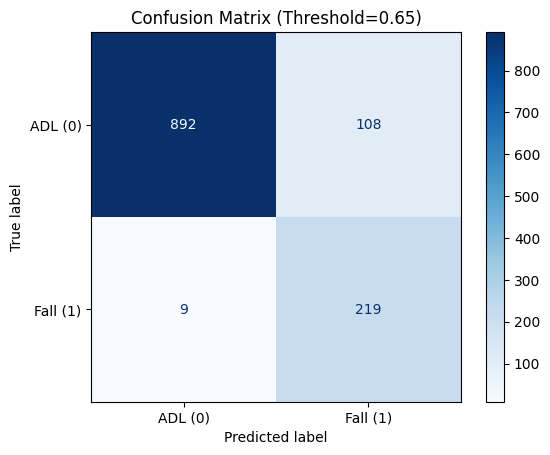

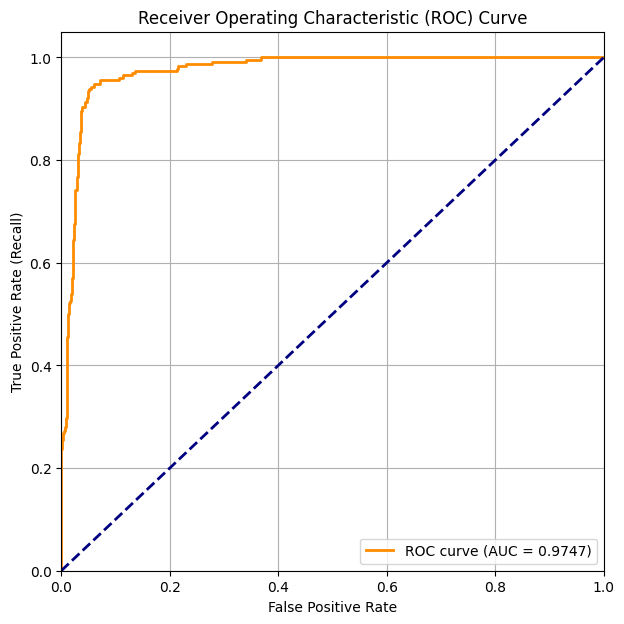

In [ ]:
# Cell 12 — Visualization of Confusion Matrix and ROC AUC
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, accuracy_score, f1_score
import torch.nn.functional as F
import numpy as np # Ensure numpy is imported if not already in the cell

THRESHOLD = 0.65 # Use the optimal threshold

# 1. Get raw prediction probabilities for the test set
def get_test_probs(model, loader, device):
    model.eval()
    all_logits = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            all_logits.append(logits.cpu().numpy())
    all_logits = np.concatenate(all_logits)
    # Get probability for the positive class (Fall, index 1)
    probs = F.softmax(torch.tensor(all_logits), dim=1)[:, 1].numpy()
    return probs

test_probs = get_test_probs(model, test_loader, device)
targets_test = y_test # Target labels (from Cell 5)

preds_test_tuned = (test_probs >= THRESHOLD).astype(int)

print(f"\n--- Visualizing Metrics for Threshold={THRESHOLD:.2f} ---")
print(f"Test Accuracy: {accuracy_score(targets_test, preds_test_tuned):.4f}")
print(f"F1-score: {f1_score(targets_test, preds_test_tuned, zero_division=0):.4f}")

# 2. Confusion Matrix Visualization
cm = confusion_matrix(targets_test, preds_test_tuned)
plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ADL (0)', 'Fall (1)'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title(f'Confusion Matrix (Threshold={THRESHOLD:.2f})')
plt.show()

# 3. ROC AUC Curve
fpr, tpr, thresholds = roc_curve(targets_test, test_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Analyzing file: /content/drive/MyDrive/AI4BM/IMU_MobiAct/Output/SDL_9_1.csv


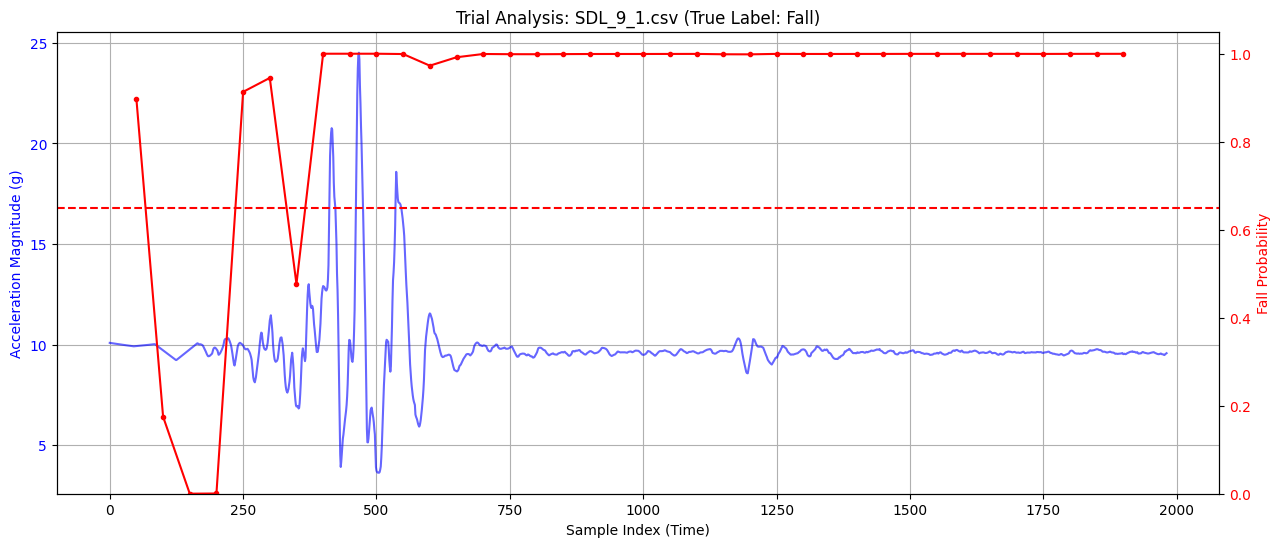

In [ ]:
# Cell 13 — Trial-Specific Visualization (Raw Data + Model Prediction)
import joblib
import torch.nn.functional as F
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define the path to the scaler (from Cell 10)
MODEL_DIR = "/content/drive/MyDrive/IMU_MobiAct/models" # Ensure this path is correct
SCALER_FILE = os.path.join(MODEL_DIR, "feature_scaler.gz")
scaler = joblib.load(SCALER_FILE)

THRESHOLD = 0.65 # The threshold to draw on the plot

# ---- Select a test file to visualize ----
# Use test_files[0] for a quick view, or change the index
# to look at a specific file (e.g., test_files[4] for another sample).
VIS_FILE = test_files[0]
print(f"Analyzing file: {VIS_FILE}")

def analyze_trial(file_path, model, scaler, device, window_size=WINDOW_SIZE, step_size=STEP_SIZE, threshold=THRESHOLD):
    # Load raw data
    df = pd.read_csv(file_path)
    df = df.ffill().bfill()

    # Segment the trial (requires segment_dataframe from Cell 4)
    segments = segment_dataframe(df, window_size, step_size, use_orientation=True)

    if segments.size == 0:
        print("No segments found for this trial."); return

    # Reshape and scale the segments (using the logic from Cell 6)
    segments_reshaped = segments.reshape(-1, segments.shape[-1])
    segments_scaled = scaler.transform(segments_reshaped).reshape(segments.shape)

    # Convert to Tensor and predict
    X_tensor = torch.tensor(segments_scaled, dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(X_tensor)
        probs = F.softmax(logits, dim=1)[:, 1].cpu().numpy() # Probability of Fall (index 1)

    # Plotting
    fig, ax1 = plt.subplots(figsize=(15, 6))

    # Plot Prediction Probability (Right Y-axis)
    window_centers = np.arange(len(probs)) * step_size + window_size / 2
    ax2 = ax1.twinx()
    ax2.plot(window_centers, probs, color='red', marker='o', markersize=3, label='Fall Probability')
    ax2.axhline(threshold, color='r', linestyle='--', label=f'Threshold ({threshold:.2f})')
    ax2.set_ylabel('Fall Probability', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_ylim(0, 1.05)

    # Plot Acceleration Magnitude (Left Y-axis)
    # SENSOR_COLS must be accessible here from Cell 2
    raw_data = df[SENSOR_COLS + ORI_COLS].values
    acc_mag = np.sqrt(raw_data[:, 0]**2 + raw_data[:, 1]**2 + raw_data[:, 2]**2)
    time_points = np.arange(len(acc_mag))
    ax1.plot(time_points, acc_mag, color='blue', alpha=0.6, label='Acc Magnitude')
    ax1.set_xlabel('Sample Index (Time)')
    ax1.set_ylabel('Acceleration Magnitude (g)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')

    # Determine the true label for the title
    # is_fall_from_filename must be accessible here from Cell 3
    true_label = "Fall" if is_fall_from_filename(file_path) else "ADL"
    ax1.set_title(f'Trial Analysis: {os.path.basename(file_path)} (True Label: {true_label})')
    ax1.grid(True)
    plt.show()

analyze_trial(VIS_FILE, model, scaler, device, threshold=THRESHOLD)

Analyzing NON-FALL file: /content/drive/MyDrive/AI4BM/IMU_MobiAct/Output/CSI_7_1.csv


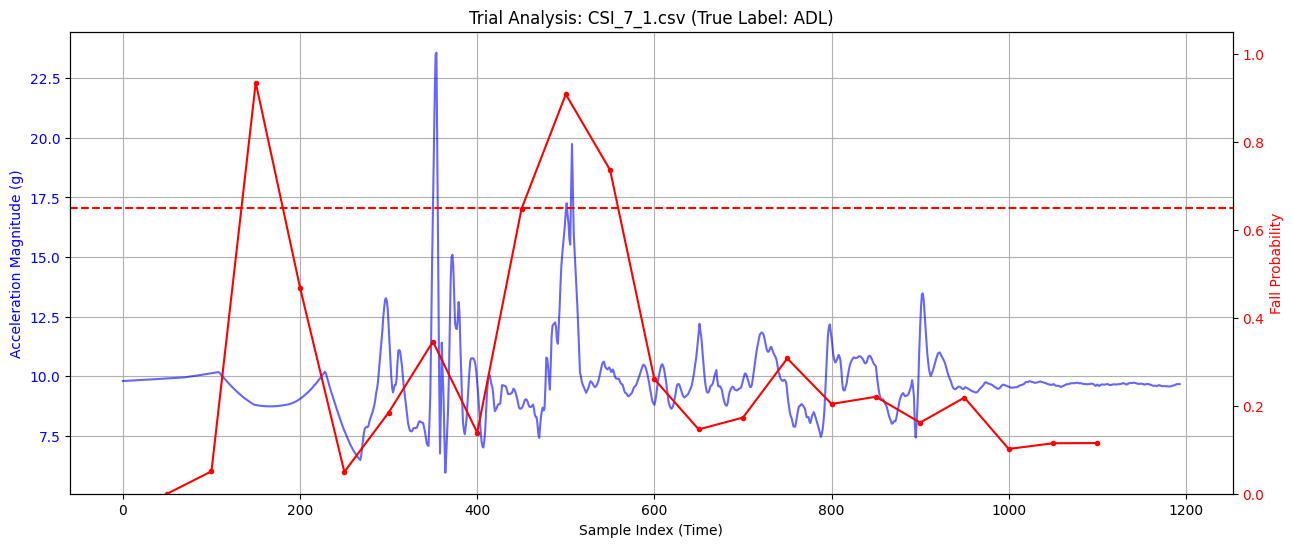

In [ ]:
# Cell 14 — Visualization of a NON-FALL (ADL) Trial (CORRECTED)
import joblib
import torch.nn.functional as F
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define the path to the scaler (from Cell 10)
MODEL_DIR = "/content/drive/MyDrive/IMU_MobiAct/models" # Ensure this path is correct
SCALER_FILE = os.path.join(MODEL_DIR, "feature_scaler.gz")
scaler = joblib.load(SCALER_FILE)

THRESHOLD = 0.65 # The threshold to draw on the plot

# ---- Select the first NON-FALL (ADL) test file to visualize ----
VIS_FILE_ADL = None
# Iterate over the test_files list to find the first file that is NOT a fall
for f in test_files:
    # is_fall_from_filename returns True for FALLS, False for ADLs
    if not is_fall_from_filename(f):
        VIS_FILE_ADL = f
        break

if VIS_FILE_ADL is None:
    raise ValueError("Could not find any non-fall (ADL) file in the test_files list.")

print(f"Analyzing NON-FALL file: {VIS_FILE_ADL}")


def analyze_trial(file_path, model, scaler, device, window_size=WINDOW_SIZE, step_size=STEP_SIZE, threshold=THRESHOLD):
    # Load raw data
    df = pd.read_csv(file_path)
    df = df.ffill().bfill()

    # Segment the trial
    segments = segment_dataframe(df, window_size, step_size, use_orientation=True)

    if segments.size == 0:
        print("No segments found for this trial."); return

    # Reshape and scale the segments
    segments_reshaped = segments.reshape(-1, segments.shape[-1])
    segments_scaled = scaler.transform(segments_reshaped).reshape(segments.shape)

    # Convert to Tensor and predict
    X_tensor = torch.tensor(segments_scaled, dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(X_tensor)
        probs = F.softmax(logits, dim=1)[:, 1].cpu().numpy() # Probability of Fall (index 1)

    # Plotting
    fig, ax1 = plt.subplots(figsize=(15, 6))

    # Plot Prediction Probability (Right Y-axis)
    window_centers = np.arange(len(probs)) * step_size + window_size / 2
    ax2 = ax1.twinx()
    ax2.plot(window_centers, probs, color='red', marker='o', markersize=3, label='Fall Probability')
    ax2.axhline(threshold, color='r', linestyle='--', label=f'Threshold ({threshold:.2f})')
    ax2.set_ylabel('Fall Probability', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_ylim(0, 1.05)

    # Plot Acceleration Magnitude (Left Y-axis)
    # SENSOR_COLS must be accessible here from Cell 2
    raw_data = df[SENSOR_COLS + ORI_COLS].values
    acc_mag = np.sqrt(raw_data[:, 0]**2 + raw_data[:, 1]**2 + raw_data[:, 2]**2)
    time_points = np.arange(len(acc_mag))
    ax1.plot(time_points, acc_mag, color='blue', alpha=0.6, label='Acc Magnitude')
    ax1.set_xlabel('Sample Index (Time)')
    ax1.set_ylabel('Acceleration Magnitude (g)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')

    # Determine the true label for the title
    true_label = "Fall" if is_fall_from_filename(file_path) else "ADL"
    ax1.set_title(f'Trial Analysis: {os.path.basename(file_path)} (True Label: {true_label})')
    ax1.grid(True)
    plt.show()

analyze_trial(VIS_FILE_ADL, model, scaler, device, threshold=THRESHOLD)

In [ ]:
# Cell 16 — Inference Speed Measurement
import time
import torch
import numpy as np # Ensure numpy is imported

NUM_WARMUP = 10  # Number of warm-up iterations
NUM_MEASURE = 100 # Number of batches to measure

# Use the test_loader, which provides data in batches (e.g., 32 windows per batch)
# We assume test_loader is still defined and accessible from Cell 7
test_data_iter = iter(test_loader)

# We assume 'model' and 'device' are defined and accessible from Cell 8

try:
    # --- 1. Warm-up Phase: Run predictions to load the model into cache ---\
    model.eval()
    for _ in range(NUM_WARMUP):
        try:
            # Get the next batch of data
            X_batch, _ = next(test_data_iter)
        except StopIteration:
            # Reset iterator if it runs out of data during warm-up
            test_data_iter = iter(test_loader)
            X_batch, _ = next(test_data_iter)

        with torch.no_grad():
            # Move to device and perform a forward pass (no timing)
            _ = model(X_batch.to(device))

    # --- 2. Measurement Phase ---\
    start_time = time.time()
    total_windows_processed = 0

    for i in range(NUM_MEASURE):
        try:
            X_batch, _ = next(test_data_iter)
        except StopIteration:
            # Reset iterator if it runs out of data during measurement
            test_data_iter = iter(test_loader)
            X_batch, _ = next(test_data_iter)

        # Count the total number of individual windows processed
        total_windows_processed += X_batch.shape[0]

        with torch.no_grad():
            # Run the prediction
            _ = model(X_batch.to(device))

    end_time = time.time()

    # --- 3. Calculation and Reporting ---\
    total_time = (end_time - start_time) # Time in seconds
    avg_time_per_window_s = total_time / total_windows_processed
    avg_time_per_window_ms = avg_time_per_window_s * 1000

    print("\n===== INFERENCE SPEED RESULTS =====")
    print(f"Total windows processed: {total_windows_processed}")
    print(f"Total time measured: {total_time:.4f} seconds")
    print(f"Average inference speed per window: {avg_time_per_window_ms:.3f} ms")

    # Check against the 40 ms goal
    if avg_time_per_window_ms <= 40.0:
        print("\nSUCCESS: Inference speed meets the 40 ms target.")
    else:
        print("\nWARNING: Inference speed exceeds the 40 ms target.")
        print(f"Target: 40.0 ms | Exceeded by: {avg_time_per_window_ms - 40.0:.3f} ms")

    print("NOTE: Results are based on the current Colab runtime (CPU/GPU) and may vary on target hardware.")

except Exception as e:
    print(f"An error occurred during timing: {e}")


===== INFERENCE SPEED RESULTS =====
Total windows processed: 3160
Total time measured: 0.1065 seconds
Average inference speed per window: 0.034 ms

SUCCESS: Inference speed meets the 40 ms target.
NOTE: Results are based on the current Colab runtime (CPU/GPU) and may vary on target hardware.
